In [1]:
import matplotlib.pyplot as plt
import matplotlib

%matplotlib tk
%autosave 180
%load_ext autoreload
%autoreload 2


import numpy as np
#%matplotlib inline
import os
from utils import *
import pandas as pd

import os


Autosaving every 180 seconds


In [74]:
################################################
################################################
################################################

class VisualizeResults():
    
    def __init__(self, 
                 root_dir,
                animal_id,
                session_id):
        
        #
        self.root_dir = root_dir
        self.animal_id = animal_id
        self.session_id = session_id
        
    def load_data(self):
        

        #
        fname = os.path.join(root_dir,
                             animal_id,
                             session_id,
                             'data', 'results.npz')
        #
        data = np.load(fname, allow_pickle=True)


        fname_dict = os.path.join(root_dir,
                             animal_id,
                             session_id,
                             'data', 'results.xlsx')

        #
        df = pd.read_excel(fname_dict)
        D = df.iloc[:,1:].values

        #
        self.white_noise = D[:,2]
        self.high_threshold = D[:,1]
        post_reward = D[:,3]

                #
        self.reward_times = np.int32(data['rewarded_times_abs'][:,1])
        print ("reward times: ", self.reward_times.shape)

        #
        self.abs_times = data['abs_times']
        print ("abs times: ", self.abs_times.shape, self.abs_times)

        self.ttl_times = data['ttl_times']
        print ("ttl times: ", self.ttl_times.shape, self.ttl_times[0], self.ttl_times[-1], " total rec time sec: ", self.ttl_times[-1]-self.ttl_times[0])

        self.ttl_comp = data['ttl_n_computed']
        print ("ttl computed: ", self.ttl_comp.shape, self.ttl_comp)

        #
        self.ttl_det = data['ttl_n_detected']
        print ("ttl detected: ", self.ttl_det.shape)

        self.lick_detector  = data['lick_detector_abstime']
        print ("lick detector: ", self.lick_detector.shape)
        #lick_detector -= lick_detector[0]
        idx = np.where(self.lick_detector >3)[0]
        self.lick_times= self.abs_times[idx]-self.ttl_times[0]
        print ("lick times: ", self.lick_times)
        #licks = result[0]/(30*33.425)

        #
        self.ttl_times -=self.ttl_times[0]

        #
        self.E = data['ensemble_diff_array']
        print (self.E.shape)

        #
        self.E1 = data["rois_traces_smooth1"]
        self.E2 = data["rois_traces_smooth2"]
        self.E1[:,:10]=0
        self.E2[:,:10]=0
        print ("E1 , E2, ", self.E1.shape, self.E2.shape)


        print ("DONE...")

        
    def show_session_traces(self):


        #
        ########################################################
        ########################################################
        ########################################################
        plt.figure()
        ax=plt.subplot(1,1,1)

        #
        scale = 2
        alpha = .7
        plt.plot(self.ttl_times,self.E1[0,self.ttl_comp], c='blue',label='roi1',alpha=alpha)
        plt.plot(self.ttl_times,self.E1[1,self.ttl_comp]+scale, c='lightblue', label='roi2',alpha=alpha)
        plt.plot(self.ttl_times,self.E2[0,self.ttl_comp]+scale*2, c='red', label='roi3',alpha=alpha)
        plt.plot(self.ttl_times,self.E2[1,self.ttl_comp]+scale*3, c='pink', label='roi4',alpha=alpha)

        # total ensemble state
        ctr=6
        plt.plot(self.ttl_times,self.E[self.ttl_comp]+scale*ctr, c='black', label='Ensemble state',alpha=.3)

        # plot rewarded times
        plt.scatter(self.ttl_times[self.reward_times],
                    self.high_threshold[self.reward_times]+scale*ctr,s=25,c='green',label='reward times')
        
        # add lines
        for k in range(self.reward_times.shape[0]):
            plt.plot([self.ttl_times[self.reward_times[k]],self.ttl_times[self.reward_times[k]]],
                    [0,self.high_threshold[self.reward_times[k]]+scale*ctr],c='green',alpha=.2)

        # plot reward threshold
        plt.plot(self.ttl_times, 
                 self.high_threshold+scale*ctr,'--',c='lightgreen', label='threshold')

        # plot white noise
        idx = np.where(self.white_noise)[0]
        ax.scatter(
                   self.ttl_times[idx], 
                   self.ttl_times[idx]*0+scale*ctr,
                   color='brown',
                   alpha=1,
            label='white-nose',
        )


        # lick times
        ctr+=.4
        plt.scatter(self.lick_times,self.lick_times*0+scale*ctr, alpha= 0.8, c='orange', label='lick detector')

        #
        plt.legend()
        plt.xlabel("Time (sec)")
        plt.xlim(self.ttl_times[0],self.ttl_times[-1])
        plt.suptitle(self.animal_id + " " + self.session_id)
        plt.show()

    #
    def compute_ensemble_correlations(self):
        
        #
        from scipy import stats
        self.E1_corr = stats.pearsonr(self.E1[0], self.E1[1])
        self.E2_corr = stats.pearsonr(self.E2[0], self.E2[1])
        
        print ("pearson correlation E1 cells; ", self.E1_corr[0])
        print ("pearson correlation E1 cells; ", self.E1_corr[0])
           
    #
    def compute_correlograms_reward_vs_licking(self):    

        from correlograms_phy import correlograms

        # rewarded times
        spikes1 = self.ttl_times[self.reward_times]

        # lick times
        spikes2 = self.lick_times


        spike_times = np.hstack((spikes1, spikes2))

        idx = np.argsort(spike_times)
        spike_times = spike_times[idx]

        spike_clusters = np.int32(np.hstack((np.zeros(spikes1.shape[0]),
                                    np.zeros(spikes2.shape[0])+1)))
        #print (spike_times.shape), spike_clusters.shape)

        #
        spike_clusters = np.int32(spike_clusters[idx])

        print (spike_times)
        soft_assignment = np.ones(spike_times.shape[0])


        corr = correlograms(spike_times,
                            spike_clusters,
                            soft_assignment,
                            cluster_ids=np.arange(2),
                            sample_rate=1,
                            bin_size=1,
                            window_size=60)


        print (corr.shape)
        plt.figure()
        titles = ['reward','lick']
        t=np.arange(corr.shape[2])-corr.shape[2]//2
        for k in range(4):
            ax=plt.subplot(2,2,k+1)
            plt.plot(t,corr[k//2,k%2], label = titles[k//2] + " vs " + titles[k%2])
            plt.legend()
            plt.xlabel("Time (sec)")
            plt.xlim(t[0],t[-1])
            plt.ylim(bottom=0)
        plt.show()

        print ("DONE...")

    #        
    def compute_correlograms_ensembles(self):    

        from correlograms_phy import correlograms

        # rewarded times
        std_threshold = 5

        #
        self.spikes_E10 = np.where(self.F_upphase_bin[0]==1)[0]
        
        #
        self.spikes_E11 = np.where(self.F_upphase_bin[1]==1)[0]
        
        #
        self.spikes_E20 = np.where(self.F_upphase_bin[2]==1)[0]

        #
        self.spikes_E21 = np.where(self.F_upphase_bin[3]==1)[0]
       
        print (self.spikes_E10.shape,
               self.spikes_E11.shape,
               self.spikes_E20.shape,
               self.spikes_E21.shape)
        
        self.E1_spikes  = self.ttl_times[self.reward_times]

        # lick times
        spike_times = np.hstack((
                                self.spikes_E10,
                                self.spikes_E11,
                                self.spikes_E20,
                                self.spikes_E21))

        idx = np.argsort(spike_times)
        spike_times = spike_times[idx]

        spike_clusters = np.int32(np.hstack((
                                    np.zeros(self.spikes_E10.shape[0]),
                                    np.zeros(self.spikes_E11.shape[0])+1,
                                    np.zeros(self.spikes_E20.shape[0])+2,
                                    np.zeros(self.spikes_E21.shape[0])+3)                                 
                                 
                                 ))
                                  
        #print (spike_times.shape), spike_clusters.shape)

        #
        spike_clusters = np.int32(spike_clusters[idx])

        print (spike_times)
        soft_assignment = np.ones(spike_times.shape[0])


        corr = correlograms(spike_times,
                            spike_clusters,
                            soft_assignment,
                            cluster_ids=np.arange(4),
                            sample_rate=1,
                            bin_size=1,
                            window_size=60)


        print (corr.shape)
        plt.figure()
        titles = ['roi1','roi2','roi3','roi4']
        t=np.arange(corr.shape[2])-corr.shape[2]//2
        for k in range(16):
            ax=plt.subplot(4,4,k+1)
            plt.plot(t,corr[k//4,k%4], label = titles[k//4] + " vs " + titles[k%4])
            plt.legend()
            plt.xlabel("Time (sec)")
            plt.xlim(t[0],t[-1])
            plt.ylim(bottom=0)
        plt.show()

        print ("DONE...")
        
    #
    def binarize_ensembles(self):
        
        from calcium import Calcium

        c = Calcium()
        c.data_dir = os.path.join(self.root_dir,
                                  self.animal_id,
                                  self.session_id)
        
        #c.detrend_model_order = 1
        c.save_python = True
        c.save_matlab=False
        c.recompute_binarization=True
        c.sample_rate = 30

        #
        c.min_width_event_onphase = c.sample_rate//2 # set minimum withd of an onphase event; default: 0.5 seconds
        c.min_width_event_upphase = c.sample_rate//4 # set minimum width of upphase event; default: 0.25 seconds

        ############# PARAMTERS TO TWEAK ##############
        #     1. Cutoff for calling somthing a spike:
        #        This is stored in: std_Fluorescence_onphase/uppohase: defaults: 1.5
        #                                        higher -> less events; lower -> more events
        #                                        start at default and increase if data is very noisy and getting too many noise-events
        c.min_thresh_std_onphase = 2.5      # set the minimum thrshold for onphase detection; defatul 2.5
        c.min_thresh_std_upphase = 2.5      # set the minimum thershold for uppohase detection; default: 2.5

        #     2. Filter of [Ca] data which smooths the data significantly more and decreases number of binarzied events within a multi-second [Ca] event
        #        This is stored in high_cutoff: default 0.5 to 1.0
        #        The lower we set it the smoother our [Ca] traces and less "choppy" the binarized traces (but we loose some temporal precision)
        c.high_cutoff = 0.5              

        #     3. Removing bleaching and drift artifacts using polynomial fits
        #        This is stored in detrend_model_order
        c.detrend_model_order = 1 # 1-5 polynomial fit


        #
        traces = np.vstack((self.E1[0],
                            self.E1[1],
                            self.E2[0],
                            self.E2[1])).astype('float32')

        #
        c.F = traces
        c.binarize_fluorescence()
        c.load_binarization()

        print ("Binarized traces: ", c.F_upphase_bin.shape)
        
        self.F_upphase_bin = c.F_upphase_bin
        self.F_filtered = c.F_filtered      
        
        

In [75]:
####################################################
################## LOAD DATA #######################
####################################################

root_dir = '/media/cat/4TB/donato/andres/'
animal_id = 'DON-012503'
session_id = '20230202'

        
vr = VisualizeResults(root_dir,
                      animal_id,
                      session_id)

vr.load_data()




reward times:  (113,)
abs times:  (3005758,) [ 163.6778394  163.6780203  163.6781784 ... 3167.3839359 3167.3855663
 3167.3857579]
ttl times:  (89953,) 167.4196949 3167.3857579  total rec time sec:  2999.966063
ttl computed:  (89953,) [    0     1     2 ... 89997 89998 89999]
ttl detected:  (89953, 1)
lick detector:  (3005758, 1)
lick times:  [   3.1840943    3.1842865    3.1860682 ... 2985.9843025 2985.9846362
 2985.9862498]
(90000,)
E1 , E2,  (2, 90000) (2, 90000)
DONE...


In [26]:
##########################################################################
############# PLOTS IN HONOR OF CAJAL AND RY #############################
##########################################################################
vr.show_session_traces()

In [201]:
##########################################################################
############# CORRELOGRAMS BETWEEN REWARDS AND LICKING ###################
##########################################################################
# this also computes a varaible vr.correlations which you can save for later analysis
vr.compute_ensemble_correlations()

#
vr.compute_correlograms_reward_vs_licking()



pearson correlation E1 cells;  0.03916222897242536
pearson correlation E1 cells;  0.03916222897242536
[   3.1004901    3.1840943    3.1842865 ... 2985.9843025 2985.9846362
 2985.9862498]
(2, 2, 61)
DONE...


In [79]:
##########################################################################
############# CORRELOGRAMS BETWEEN BINARIZED TIME SERIES #################
##########################################################################

#
vr.binarize_ensembles()

#
vr.compute_correlograms_ensembles()

model filter: remove bleaching or trends: 100%|██████████████████████████████████████████████████████| 4/4 [00:00<00:00, 1799.55it/s]


too few cells... for std global


binarizing continuous traces filtered fluorescence onphase: 100%|█████████████████████████████████████| 4/4 [00:00<00:00, 770.55it/s]
binarizing continuous traces filtered fluorescence upphase: 100%|█████████████████████████████████████| 4/4 [00:00<00:00, 355.32it/s]


   Oasis based binarization skipped by default ... 


model filter: remove bleaching or trends: 100%|██████████████████████████████████████████████████████| 4/4 [00:00<00:00, 1497.30it/s]


too few cells... for std global


binarizing continuous traces filtered fluorescence onphase: 100%|█████████████████████████████████████| 4/4 [00:00<00:00, 549.82it/s]
binarizing continuous traces filtered fluorescence upphase: 100%|█████████████████████████████████████| 4/4 [00:00<00:00, 349.45it/s]


   Oasis based binarization skipped by default ... 
Binarized traces:  (4, 90000)
(360,) (878,) (1206,) (2797,)
[  295   296   297 ... 88599 88600 88601]
(4, 4, 61)
DONE...


In [69]:
################################################
############### SIMPLE VIS TEST ################
################################################
plt.figure()

plt.plot(vr.F_upphase_bin[0])
plt.plot(vr.F_filtered[0])
plt.plot(vr.E1[0])


plt.show()

[   3.1004901    3.1840943    3.1842865 ... 2985.9843025 2985.9846362
 2985.9862498]
DONE...


(2, 2, 31)


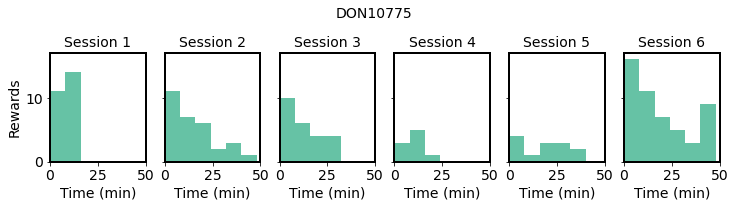

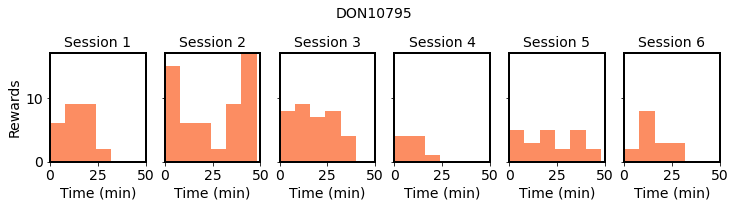

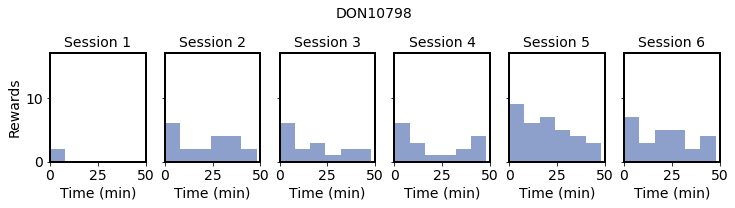

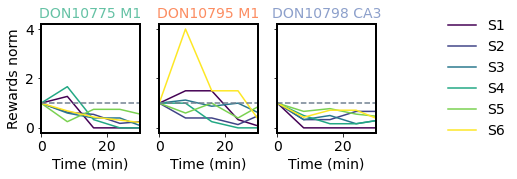

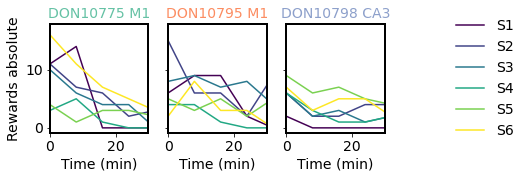

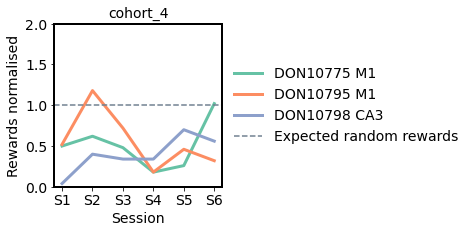

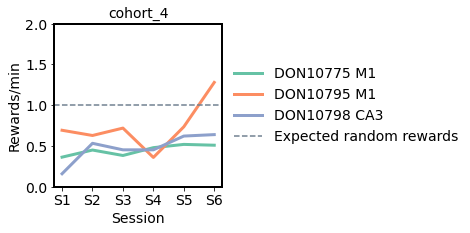

In [69]:
learning = []
learning_curves = []
early_learning = []
for i in range(len(mice)):
    plot_features_mouse(root_dir, mice[i], dates[i], filename,cohort, out_dir)
    learning_mouse, learning_curve, early_mouse = plot_histogram_mouse(mice[i], dates[i], root_dir, filename, cmap(i), out_dir,cohort,bin_size)
    learning.append(learning_mouse)
    learning_curves.append(learning_curve)
    early_learning.append(early_mouse)
    #plot_images_mouse(mice[i], dates[i], cohort, root_dir, out_dir)
plot_learning_curve(mice, learning_curves, mice_type, out_dir, cohort,bin_size)
plot_learning_curve(mice, learning_curves, mice_type, out_dir, cohort,bin_size, normalise=False)
plot_rewards_cohort(mice, learning, early_learning, mice_type, out_dir, cohort, cmap, bin_size)
plot_rewards_cohort(mice, learning, early_learning, mice_type, out_dir, cohort, cmap, bin_size, normalise=False)

In [72]:
################################################################
#################### DEBUG LAG ISSUE ###########################
################################################################

ttl_comp = data['ttl_n_computed']

plt.figure()
ax=plt.subplot(111)
diffs = ((ttl_comp[1:]-ttl_comp[:-1])-1)/30.

t = ttl_times - ttl_times[0]
t = t[:-1]
plt.plot(t,diffs, c='blue',
        label= 'diffs betwen frames')
#plt.xlim(x[0],x[-1])
plt.ylabel("Error in timing between sequetial frames (0 is ideal) (# frames)")
plt.xlabel("Time (sec)")


vv = data['ttl_voltages']
offset = (ttl_times[0]-abs_times[0])
tt = abs_times 
tt = tt-tt[0]- offset
plt.plot(tt, vv, label='whileloop reads')
plt.legend()
#plt.plot(ttl_comp)

#
ax2=ax.twinx()
cumsum = np.cumsum(diffs)

plt.plot(t,cumsum, c='red',
        )
#plt.xlim(x[0],x[-1])

plt.ylabel("Cumulative Lag")
plt.show()


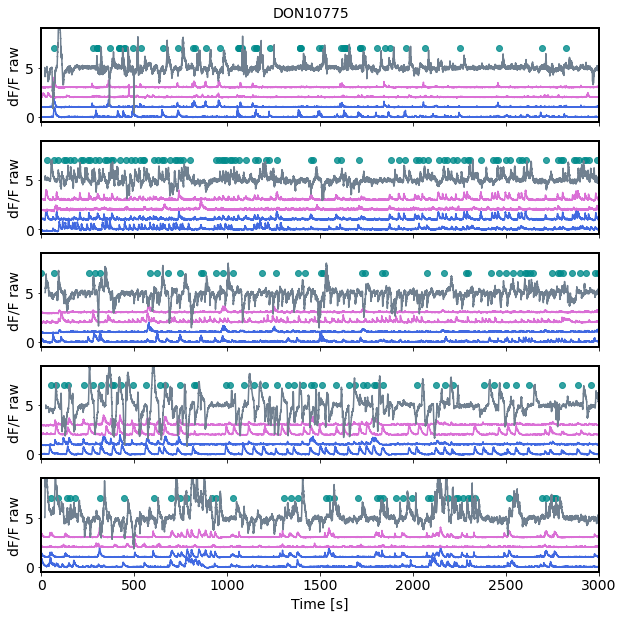

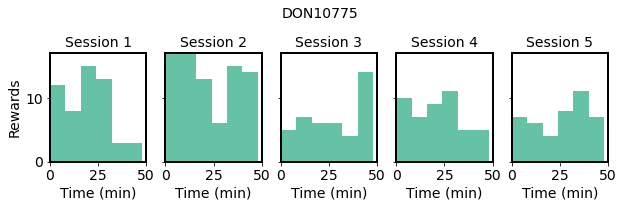

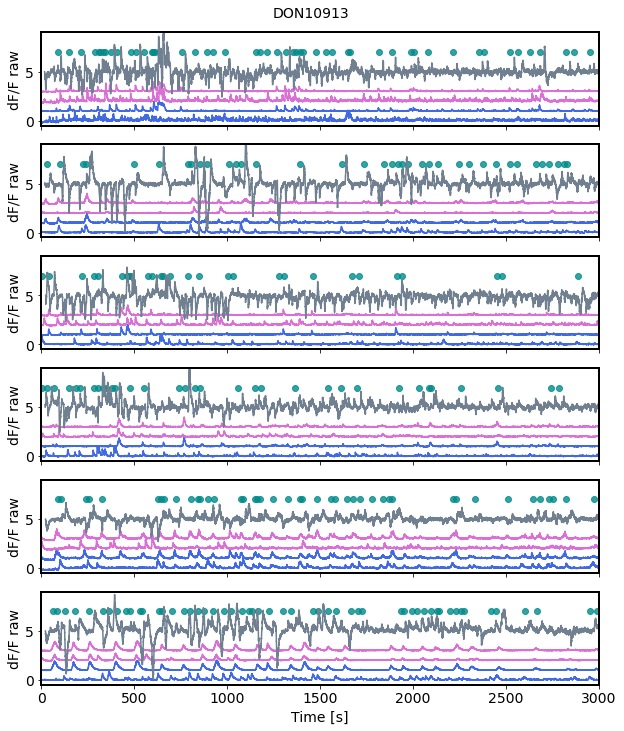

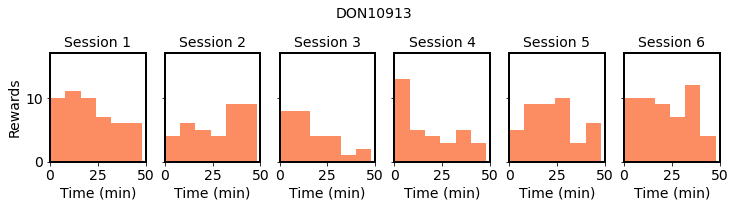

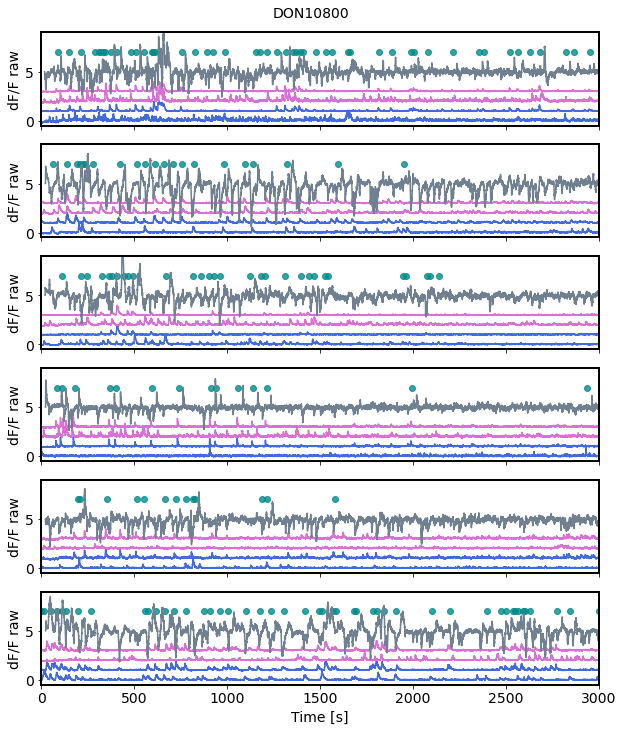

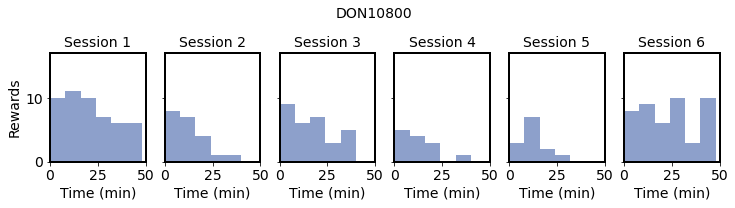

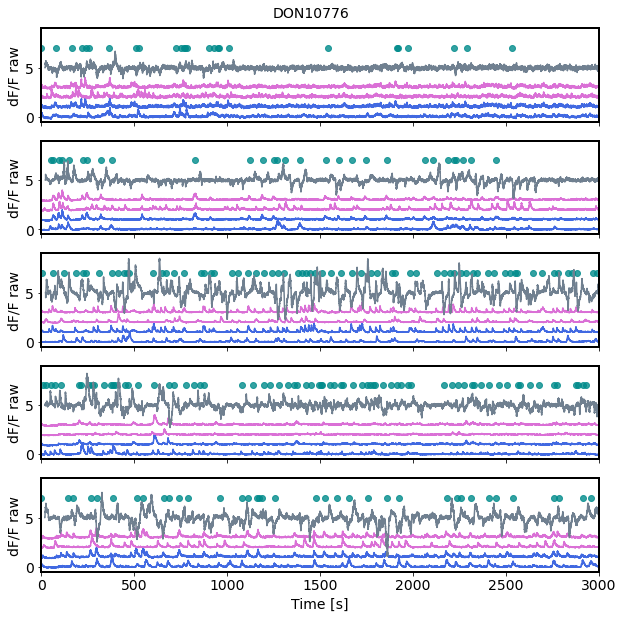

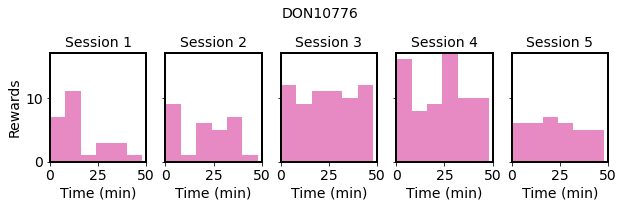

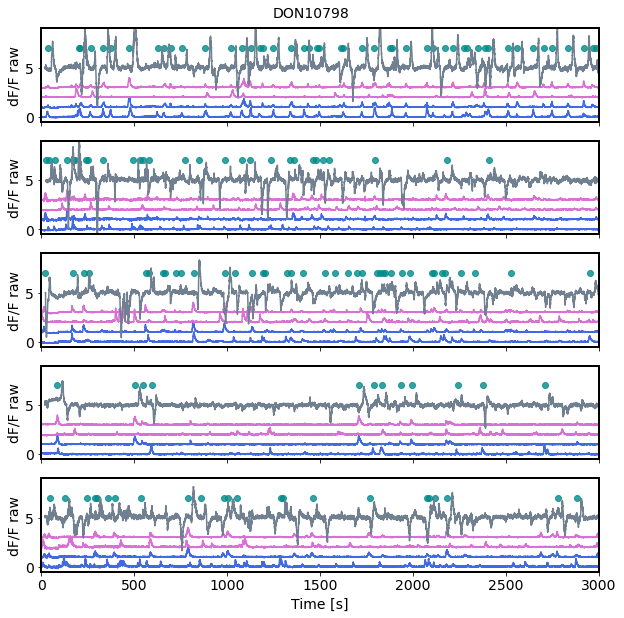

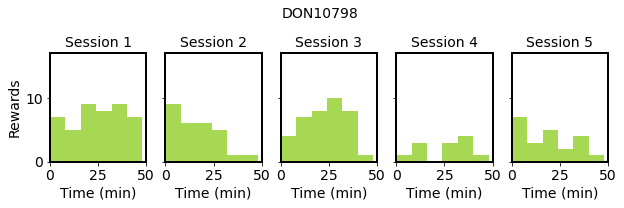

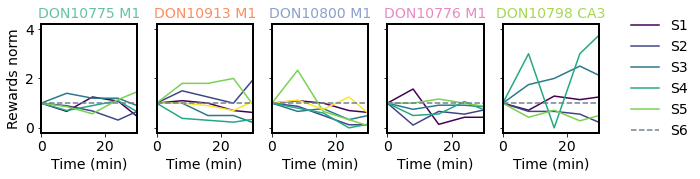

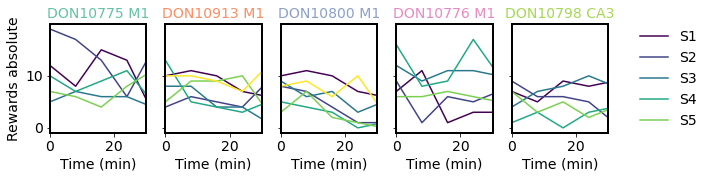

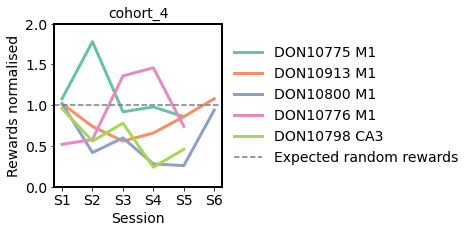

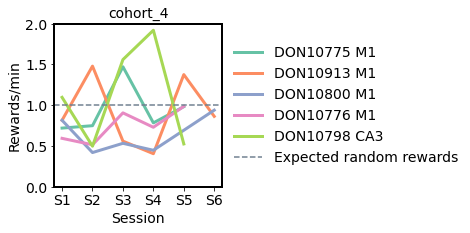

In [73]:
learning = []
learning_curves = []
early_learning = []
for i in range(len(mice)):
    plot_features_mouse(root_dir, mice[i], dates[i], filename,cohort, out_dir)
    learning_mouse, learning_curve, early_mouse = plot_histogram_mouse(mice[i], dates[i], root_dir, filename, cmap(i), out_dir,cohort,bin_size)
    learning.append(learning_mouse)
    learning_curves.append(learning_curve)
    early_learning.append(early_mouse)
    #plot_images_mouse(mice[i], dates[i], cohort, root_dir, out_dir)
plot_learning_curve(mice, learning_curves, mice_type, out_dir, cohort,bin_size)
plot_learning_curve(mice, learning_curves, mice_type, out_dir, cohort,bin_size, normalise=False)
plot_rewards_cohort(mice, learning, early_learning, mice_type, out_dir, cohort, cmap, bin_size)
plot_rewards_cohort(mice, learning, early_learning, mice_type, out_dir, cohort, cmap, bin_size, normalise=False)
